# AI Incident Story Draft

This notebook builds a data story from the AI incident dataset step by step.

**Recommended story thesis:** Since 2023, the center of gravity of AI harm has shifted from accidental system failures toward intentional misuse, misinformation, and socially scaled harms.

This notebook is organized to support that claim with a clean sequence of charts.

## 1. Setup

Load the incident, report, and classification tables. The core grain is one row per incident in `incidents.csv`.

In [1]:
from pathlib import Path
import ast
from collections import Counter

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

In [2]:
ROOT = Path.cwd()
if not (ROOT / 'data').exists():
    ROOT = ROOT.parent

DATA = ROOT / 'data'

incidents = pd.read_csv(DATA / 'incidents.csv')
reports = pd.read_csv(DATA / 'reports.csv')
mit = pd.read_csv(DATA / 'classifications_MIT.csv')
gmf = pd.read_csv(DATA / 'classifications_GMF.csv')
cset = pd.read_csv(DATA / 'classifications_CSETv1.csv')
duplicates = pd.read_csv(DATA / 'duplicates.csv')

incidents['date'] = pd.to_datetime(incidents['date'], errors='coerce')
incidents['year'] = incidents['date'].dt.year

def parse_report_ids(value):
    if pd.isna(value):
        return []
    try:
        parsed = ast.literal_eval(value)
        return parsed if isinstance(parsed, list) else []
    except (ValueError, SyntaxError):
        return []

incidents['report_ids'] = incidents['reports'].apply(parse_report_ids)
incidents['report_count'] = incidents['report_ids'].apply(len)

print('incidents', incidents.shape)
print('reports', reports.shape)
print('mit', mit.shape)
print('gmf', gmf.shape)
print('cset', cset.shape)

incidents (1473, 12)
reports (7007, 21)
mit (1242, 8)
gmf (326, 21)
cset (214, 65)


## 2. Quick Structure Check

Use this to confirm the main tables and their roles before charting.

In [3]:
display(incidents.head(3))
display(mit.head(3))
display(gmf.head(3))
display(cset.head(3))

,_id,incident_id,date,reports,Alleged deployer of AI system,Alleged developer of AI system,Alleged harmed or nearly harmed parties,description,title,year,report_ids,report_count
0,ObjectId(625763de343edc875fe63a15),23,2017-11-08,"[242,243,244,245,246,247,248,249,250,253,254,2...","[""navya"",""keolis-north-america""]","[""navya"",""keolis-north-america""]","[""navya"",""keolis-north-america"",""bus-passengers""]",A self-driving public shuttle by Keolis North ...,Las Vegas Self-Driving Bus Involved in Accident,2017,"[242, 243, 244, 245, 246, 247, 248, 249, 250, ...",23
1,ObjectId(625763dc343edc875fe63a02),4,2018-03-18,"[629,630,631,632,633,634,635,636,637,638,639,6...","[""uber""]","[""uber""]","[""elaine-herzberg"",""pedestrians""]",An Uber autonomous vehicle (AV) in autonomous ...,Uber AV Killed Pedestrian in Arizona,2018,"[629, 630, 631, 632, 633, 634, 635, 636, 637, ...",25
2,ObjectId(625763db343edc875fe639ff),1,2015-05-19,"[2,3,4,5,6,7,8,9,10,11,12,14,15,7175]","[""youtube""]","[""youtube""]","[""children""]",YouTube’s content filtering and recommendation...,Google’s YouTube Kids App Presents Inappropria...,2015,"[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 7...",14


,Namespace,Incident ID,Published,Risk Domain,Risk Subdomain,Entity,Timing,Intent
0,MIT,1,True,1. Discrimination and Toxicity,1.2. Exposure to toxic content,AI,Post-deployment,Unintentional
1,MIT,2,True,"7. AI system safety, failures, and limitations",7.3. Lack of capability or robustness,AI,Post-deployment,Unintentional
2,MIT,3,True,"7. AI system safety, failures, and limitations",7.3. Lack of capability or robustness,AI,Post-deployment,Unintentional


,Namespace,Incident ID,Published,Known AI Goal,Known AI Goal Snippets,Known AI Goal Classification Discussion,Potential AI Goal,Potential AI Goal Snippets,Potential AI Goal Classification Discussion,Known AI Technology,...,Known AI Technology Classification Discussion,Potential AI Technology,Potential AI Technology Snippets,Potential AI Technology Classification Discussion,Known AI Technical Failure,Known AI Technical Failure Snippets,Known AI Technical Failure Classification Discussion,Potential AI Technical Failure,Potential AI Technical Failure Snippets,Potential AI Technical Failure Classification Discussion
0,GMF,1,True,"Content Recommendation, Content Search, Hate S...",Snippet Text: An off-brand Paw Patrol video ca...,NaN,NaN,NaN,NaN,"Content-based Filtering, Collaborative Filtering",...,NaN,"Classification, Ensemble Aggregation, Distribu...",Snippet Text: \nPart of YouTube’s plan is to i...,Classification: Appropriateness could arise by...,"Tuning Issues, Lack of Adversarial Robustness,...",Snippet Text: \nPart of YouTube’s plan is to i...,"Tuning Issues: Default classification, in case...","Concept Drift, Generalization Failure, Misconf...","Snippet Text: “From a child standpoint, the pr...",Concept Drift: Concept drift in cases where ap...
1,GMF,10,True,"Market Forecasting, Scheduling",NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,"Regression, Diverse Data",Snippet Text: “You’re waiting on your job to c...,Regression: Potentially the number of required...,Underspecification,Snippet Text: “You’re waiting on your job to c...,Underspecification: System is not designed to ...,"Tuning Issues, Misconfigured Aggregation","Snippet Text: In addition, Kronos is improving...",Tuning Issues: Weight of employee preferences ...
2,GMF,13,True,Hate Speech Detection,"Snippet Text: However, computer scientists and...",NaN,NaN,NaN,NaN,Character NGrams,...,NaN,Distributional Learning,Snippet Text: The Google AI tool used to flag ...,NaN,"Context Misidentification, Generalization Fail...",Snippet Text: “This is essentially finding ‘go...,NaN,"Limited Dataset, Misaligned Objective, Underfi...",Snippet Text: It’s very limited to the types o...,Data or Labelling Noise: Potentially profanity...


,Namespace,Incident ID,Published,Incident Number,Annotator,Annotation Status,Peer Reviewer,Quality Control,Physical Objects,Entertainment Industry,...,Data Inputs,Sector of Deployment,Public Sector Deployment,Autonomy Level,Notes (Information about AI System),Intentional Harm,Physical System Type,AI Task,AI tools and methods,Notes (AI Functionality and Techniques)
0,CSETv1,250,False,0,NaN,--,NaN,False,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,CSETv1,208,False,0,NaN,--,NaN,False,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,CSETv1,204,False,0,NaN,--,NaN,False,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
summary = pd.DataFrame({
    'table': ['incidents', 'reports', 'mit', 'gmf', 'cset'],
    'rows': [len(incidents), len(reports), len(mit), len(gmf), len(cset)],
    'primary_use': [
        'Main incident-level dataset',
        'Source articles and evidence layer',
        'Risk taxonomy, timing, intent',
        'Technical goals, technology, failure modes',
        'Harm severity, sector, autonomy, rights, public sector'
    ]
})
summary

,table,rows,primary_use
0,incidents,1473,Main incident-level dataset
1,reports,7007,Source articles and evidence layer
2,mit,1242,"Risk taxonomy, timing, intent"
3,gmf,326,"Technical goals, technology, failure modes"
4,cset,214,"Harm severity, sector, autonomy, rights, publi..."


## 3. Chart 1: Incident Growth Over Time

This establishes scale and shows how sharply incident counts accelerate in recent years.

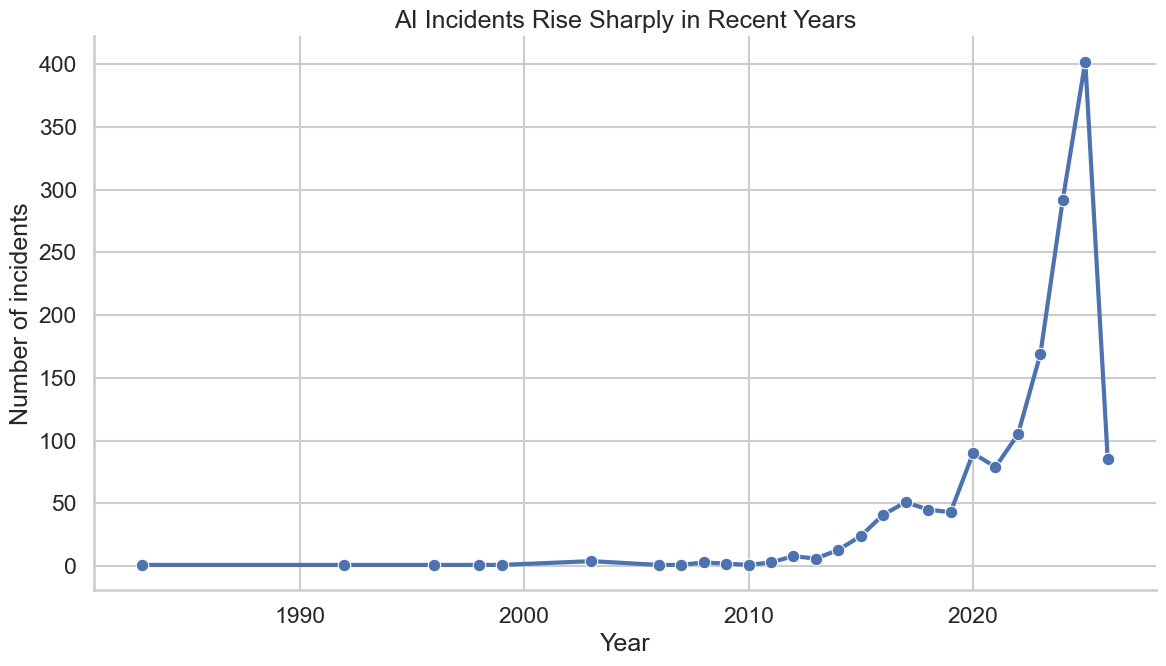

,year,incident_count
17,2017,51
18,2018,45
19,2019,43
20,2020,90
21,2021,79
22,2022,105
23,2023,169
24,2024,292
25,2025,402
26,2026,85


In [5]:
year_counts = (
    incidents.dropna(subset=['year'])
    .groupby('year', as_index=False)
    .size()
    .rename(columns={'size': 'incident_count'})
)

ax = sns.lineplot(data=year_counts, x='year', y='incident_count', marker='o', linewidth=3)
ax.set_title('AI Incidents Rise Sharply in Recent Years')
ax.set_xlabel('Year')
ax.set_ylabel('Number of incidents')
plt.tight_layout()
plt.show()

year_counts.tail(10)

## 4. Join MIT Taxonomy to Incident Dates

The MIT table provides the clearest framing for the main story: what type of harm is being reported, when, and whether it was intentional.

In [6]:
mit_story = mit.merge(
    incidents[['incident_id', 'date', 'year', 'title', 'report_count']],
    left_on='Incident ID',
    right_on='incident_id',
    how='left'
)

mit_story['Risk Domain'] = mit_story['Risk Domain'].fillna('Unknown')
mit_story['Intent'] = mit_story['Intent'].fillna('Unknown')
mit_story[['Incident ID', 'title', 'year', 'Risk Domain', 'Intent']].head()

,Incident ID,title,year,Risk Domain,Intent
0,1,Google’s YouTube Kids App Presents Inappropria...,2015,1. Discrimination and Toxicity,Unintentional
1,2,Warehouse robot ruptures can of bear spray and...,2018,"7. AI system safety, failures, and limitations",Unintentional
2,3,Crashes with Maneuvering Characteristics Augme...,2018,"7. AI system safety, failures, and limitations",Unintentional
3,4,Uber AV Killed Pedestrian in Arizona,2018,"7. AI system safety, failures, and limitations",Unintentional
4,5,Collection of Robotic Surgery Malfunctions,2015,"7. AI system safety, failures, and limitations",Unintentional


## 5. Chart 2: Risk Domains by Year

This is the main chart for the story. Focus on 2021 onward so the recent transition is visible.

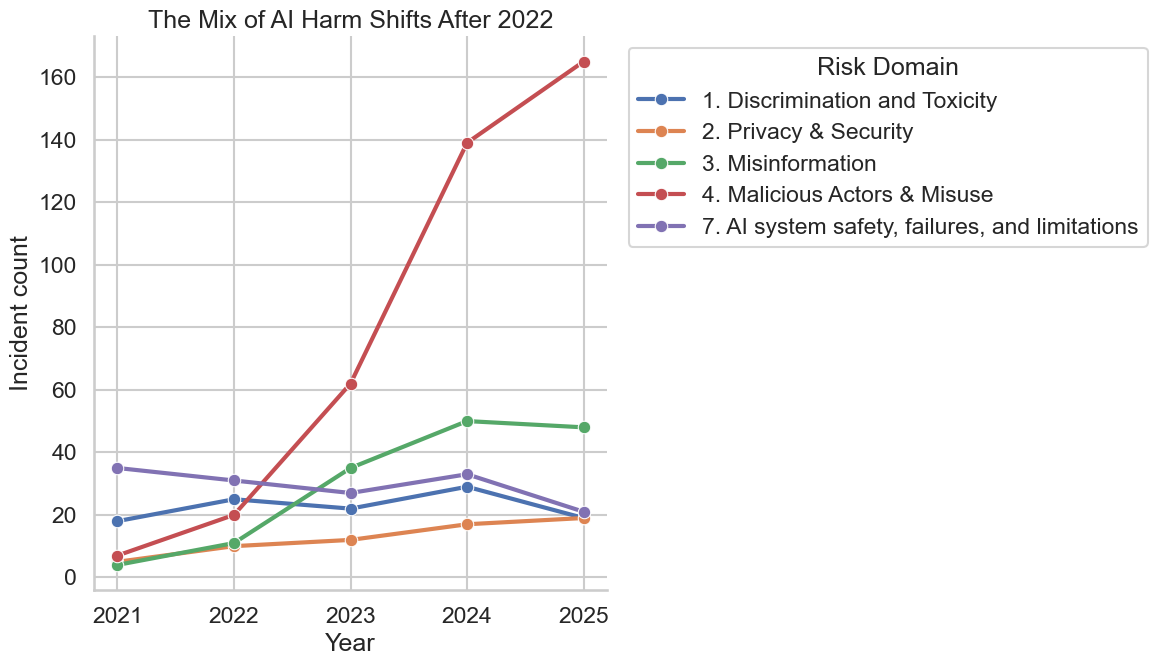

,year,Risk Domain,incident_count
4,2021,"7. AI system safety, failures, and limitations",35
0,2021,1. Discrimination and Toxicity,18
3,2021,4. Malicious Actors & Misuse,7
1,2021,2. Privacy & Security,5
2,2021,3. Misinformation,4
9,2022,"7. AI system safety, failures, and limitations",31
5,2022,1. Discrimination and Toxicity,25
8,2022,4. Malicious Actors & Misuse,20
7,2022,3. Misinformation,11
6,2022,2. Privacy & Security,10


In [7]:
recent_mit = mit_story[mit_story['year'] >= 2021].copy()

top_domains = (
    recent_mit['Risk Domain']
    .value_counts()
    .head(5)
    .index
)

risk_by_year = (
    recent_mit[recent_mit['Risk Domain'].isin(top_domains)]
    .groupby(['year', 'Risk Domain'], as_index=False)
    .size()
    .rename(columns={'size': 'incident_count'})
)

ax = sns.lineplot(
    data=risk_by_year,
    x='year',
    y='incident_count',
    hue='Risk Domain',
    marker='o',
    linewidth=3
)
ax.set_title('The Mix of AI Harm Shifts After 2022')
ax.set_xlabel('Year')
ax.set_ylabel('Incident count')
plt.legend(title='Risk Domain', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

risk_by_year.sort_values(['year', 'incident_count'], ascending=[True, False]).head(20)

## 6. Chart 3: Intentional vs Unintentional Incidents

This directly supports the claim that the dominant incident pattern becomes more deliberate over time.

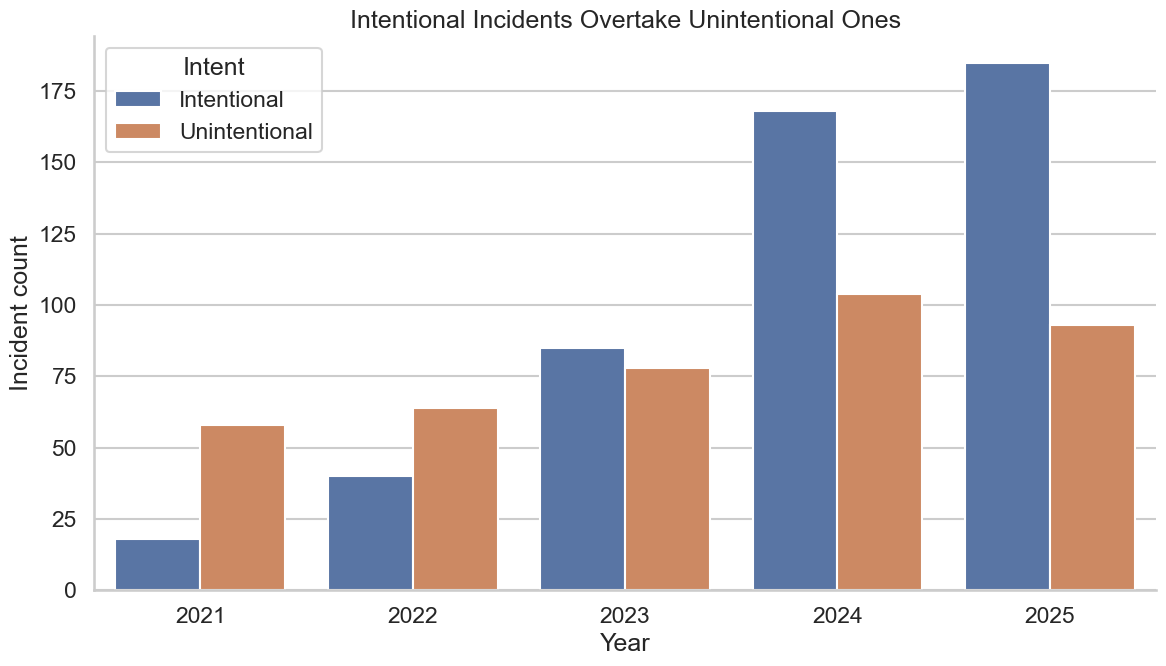

Intent,Intentional,Unintentional
year,,
2021,18,58
2022,40,64
2023,85,78
2024,168,104
2025,185,93


In [8]:
intent_by_year = (
    recent_mit[recent_mit['Intent'].isin(['Intentional', 'Unintentional'])]
    .groupby(['year', 'Intent'], as_index=False)
    .size()
    .rename(columns={'size': 'incident_count'})
)

ax = sns.barplot(data=intent_by_year, x='year', y='incident_count', hue='Intent')
ax.set_title('Intentional Incidents Overtake Unintentional Ones')
ax.set_xlabel('Year')
ax.set_ylabel('Incident count')
plt.tight_layout()
plt.show()

intent_by_year.pivot(index='year', columns='Intent', values='incident_count').fillna(0)

## 7. Chart 4: Misinformation and Misuse Acceleration

If you want a cleaner presentation chart, isolate the two recent categories that expand fastest.

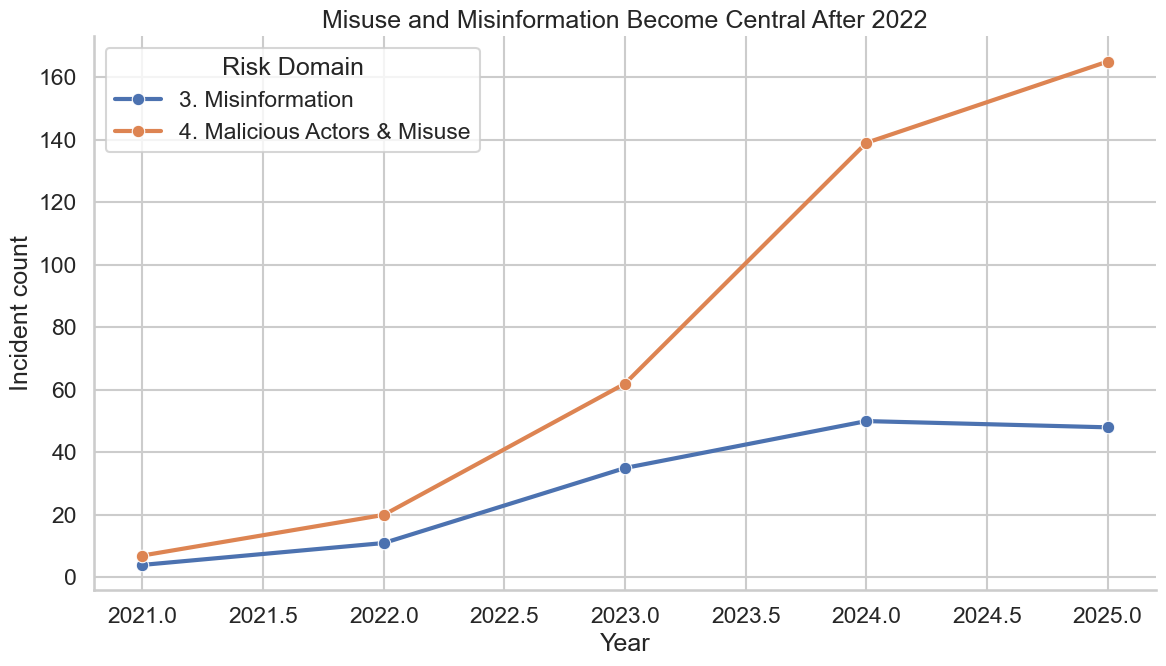

In [9]:
focus_domains = [
    '4. Malicious Actors & Misuse',
    '3. Misinformation'
]

focus_risk = (
    recent_mit[recent_mit['Risk Domain'].isin(focus_domains)]
    .groupby(['year', 'Risk Domain'], as_index=False)
    .size()
    .rename(columns={'size': 'incident_count'})
)

ax = sns.lineplot(data=focus_risk, x='year', y='incident_count', hue='Risk Domain', marker='o', linewidth=3)
ax.set_title('Misuse and Misinformation Become Central After 2022')
ax.set_xlabel('Year')
ax.set_ylabel('Incident count')
plt.tight_layout()
plt.show()

## 8. Join GMF Technical Failure Labels

Use the GMF table to explain what is breaking at the technical level behind the visible social harms.

In [10]:
gmf_story = gmf.merge(
    incidents[['incident_id', 'date', 'year', 'title']],
    left_on='Incident ID',
    right_on='incident_id',
    how='left'
)

gmf_story = gmf_story[gmf_story['Known AI Technical Failure'].notna()].copy()
gmf_story = gmf_story.assign(
    failure=gmf_story['Known AI Technical Failure'].str.split(',')
).explode('failure')
gmf_story['failure'] = gmf_story['failure'].str.strip()
gmf_story = gmf_story[gmf_story['failure'].ne('')]

gmf_story[['Incident ID', 'year', 'title', 'failure']].head()

,Incident ID,year,title,failure
0,1,2015,Google’s YouTube Kids App Presents Inappropria...,Tuning Issues
0,1,2015,Google’s YouTube Kids App Presents Inappropria...,Lack of Adversarial Robustness
0,1,2015,Google’s YouTube Kids App Presents Inappropria...,Adversarial Data
1,10,2014,Kronos Scheduling Algorithm Allegedly Caused F...,Underspecification
2,13,2017,High-Toxicity Assessed on Text Involving Women...,Context Misidentification


## 9. Chart 5: Technical Failure Modes Behind Recent Incidents

This gives the audience a technical explanation layer. `Misinformation Generation Hazard` and `Unsafe Exposure or Access` are especially relevant for generative AI era incidents.

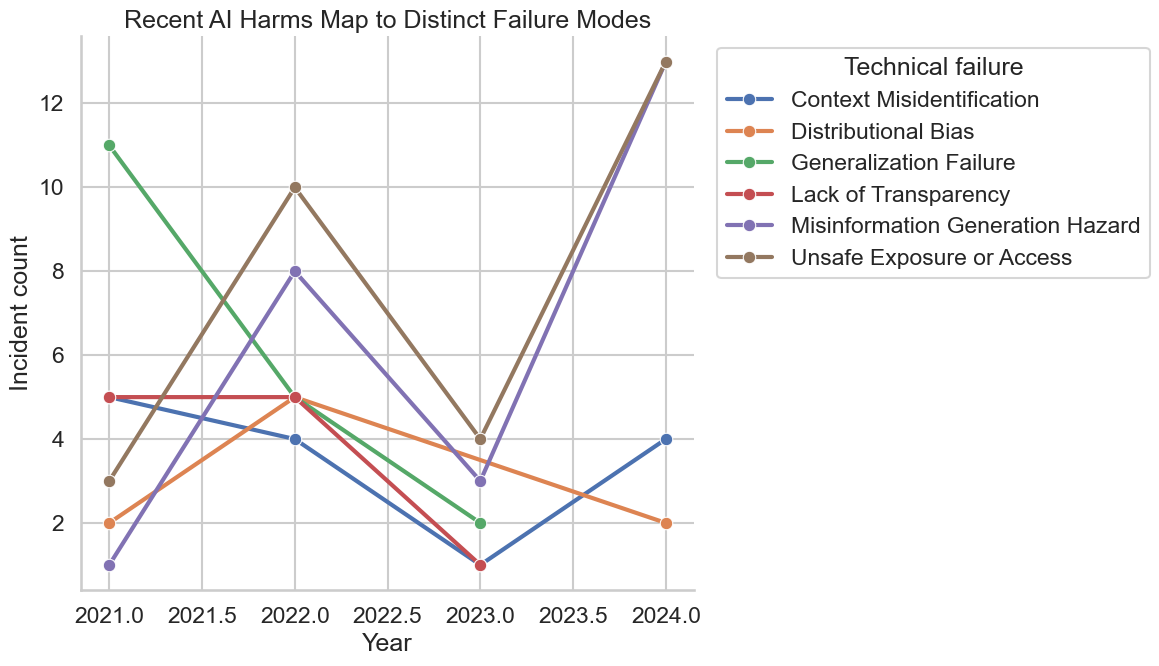

In [11]:
recent_failures = gmf_story[gmf_story['year'] >= 2021].copy()

top_failures = recent_failures['failure'].value_counts().head(6).index
failure_by_year = (
    recent_failures[recent_failures['failure'].isin(top_failures)]
    .groupby(['year', 'failure'], as_index=False)
    .size()
    .rename(columns={'size': 'incident_count'})
)

ax = sns.lineplot(data=failure_by_year, x='year', y='incident_count', hue='failure', marker='o', linewidth=3)
ax.set_title('Recent AI Harms Map to Distinct Failure Modes')
ax.set_xlabel('Year')
ax.set_ylabel('Incident count')
plt.legend(title='Technical failure', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 10. Chart 6: Which Incidents Get the Most Attention?

Because each incident links to many source reports, `report_count` is a reasonable proxy for media attention inside this dataset.

/var/folders/st/3lhx8lh109n5pxkwk6s4s6040000gn/T/ipykernel_10631/2225650111.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=top_attention, x='report_count', y='title', palette='crest')
/var/folders/st/3lhx8lh109n5pxkwk6s4s6040000gn/T/ipykernel_10631/2225650111.py:12: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


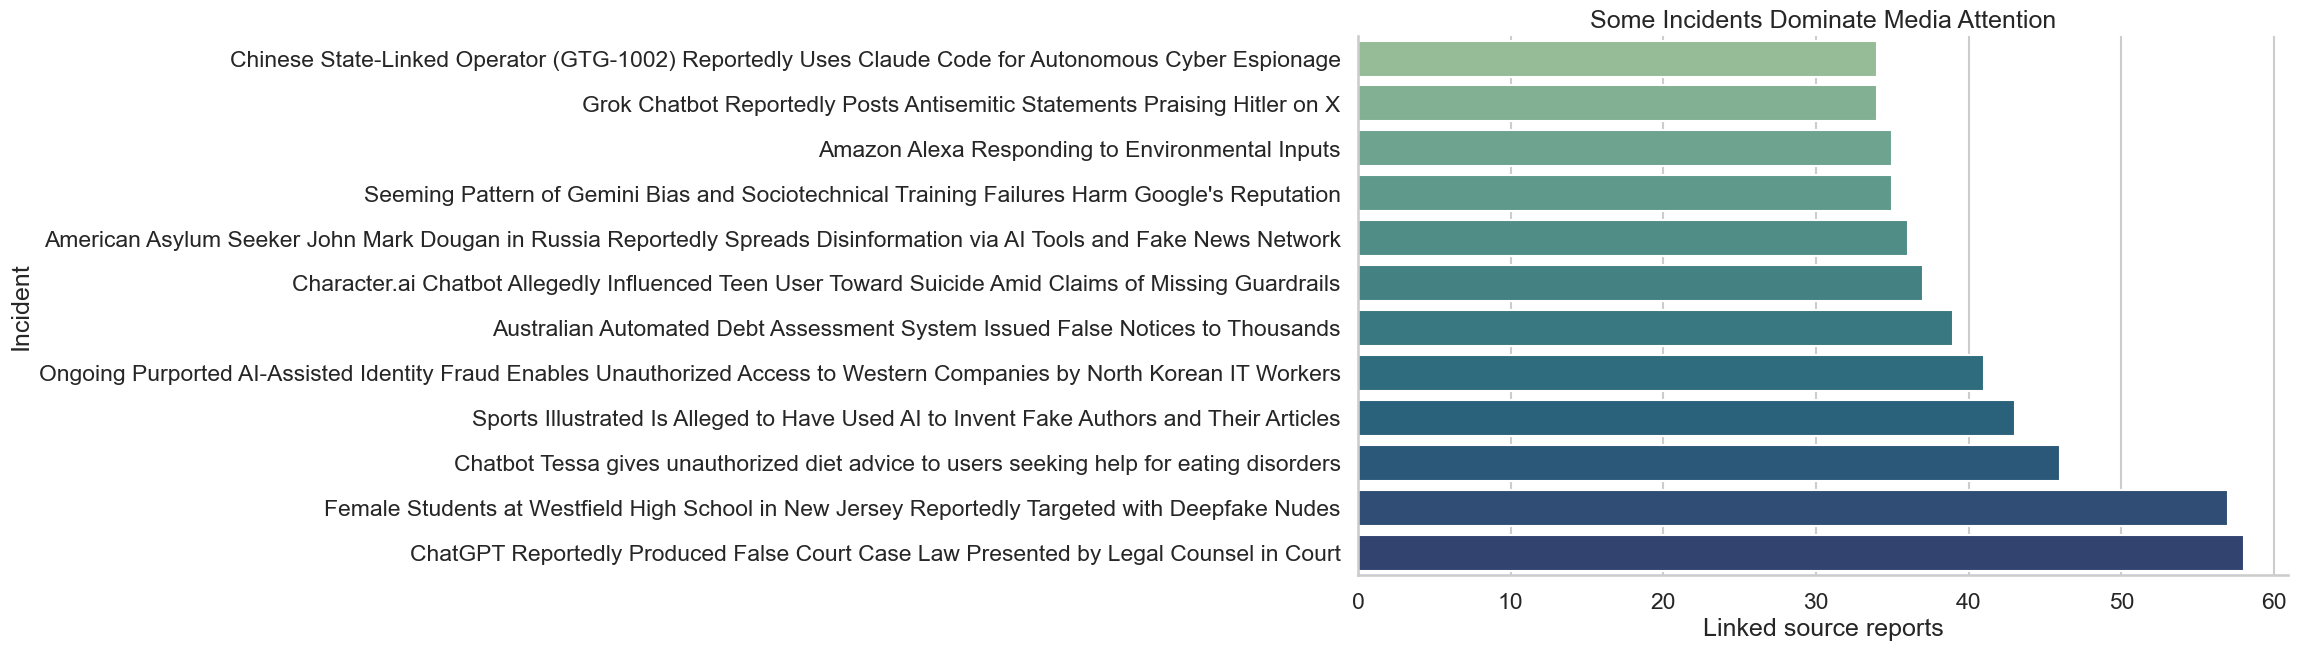

,date,title,report_count
530,2023-05-04,ChatGPT Reportedly Produced False Court Case L...,58
585,2023-10-20,Female Students at Westfield High School in Ne...,57
533,2023-05-29,Chatbot Tessa gives unauthorized diet advice t...,46
604,2023-11-27,Sports Illustrated Is Alleged to Have Used AI ...,43
1106,2021-01-01,Ongoing Purported AI-Assisted Identity Fraud E...,41
63,2015-07-01,Australian Automated Debt Assessment System Is...,39
814,2024-02-28,Character.ai Chatbot Allegedly Influenced Teen...,37
689,2024-05-29,American Asylum Seeker John Mark Dougan in Rus...,36
27,2015-12-05,Amazon Alexa Responding to Environmental Inputs,35
633,2024-02-21,Seeming Pattern of Gemini Bias and Sociotechni...,35


In [12]:
top_attention = (
    incidents[['incident_id', 'date', 'title', 'report_count']]
    .sort_values('report_count', ascending=False)
    .head(12)
    .sort_values('report_count')
)

ax = sns.barplot(data=top_attention, x='report_count', y='title', palette='crest')
ax.set_title('Some Incidents Dominate Media Attention')
ax.set_xlabel('Linked source reports')
ax.set_ylabel('Incident')
plt.tight_layout()
plt.show()

top_attention[['date', 'title', 'report_count']].sort_values('report_count', ascending=False)

## 11. Optional: Public Sector and Sector-of-Deployment View

Use this if you want a policy-oriented ending rather than a purely technical one.

In [13]:
cset_clean = cset.copy()
cset_clean['Public Sector Deployment'] = cset_clean['Public Sector Deployment'].fillna('unknown')
cset_clean['Sector of Deployment'] = cset_clean['Sector of Deployment'].fillna('Unknown')

display(cset_clean['Public Sector Deployment'].value_counts(dropna=False))
display(cset_clean['Sector of Deployment'].value_counts().head(12))

Public Sector Deployment
no         158
yes         41
unknown     12
maybe        3
Name: count, dtype: int64

Sector of Deployment
information and communication                                        44
transportation and storage                                           21
Arts, entertainment and recreation, information and communication    14
Unknown                                                              13
wholesale and retail trade                                           11
human health and social work activities                              10
law enforcement                                                       9
Arts, entertainment and recreation                                    9
information and communication, Arts, entertainment and recreation     9
Education                                                             7
administrative and support service activities                         5
public administration                                                 4
Name: count, dtype: int64

## 12. Suggested Final Storyboard

If you need a concise presentation sequence, use this order:

1. Incident growth over time
2. Risk domain shift after 2022
3. Intentional vs unintentional split
4. Technical failure modes behind recent harms
5. Most-covered incidents as concrete case studies

**Narrative close:** AI risk used to be framed mainly as system failure. The recent incident record shows a broader and more urgent reality: AI is increasingly being used intentionally to scale deception, manipulation, and other social harms.